# Linear Regression Endpoint Recovery with Callback-Selected Early Stopping

This notebook keeps the same early-stopping rule as `linear-regression.ipynb`, but now focuses only on the endpoint-based estimators. Because the model is exact full-batch GD, the callback rule is emulated analytically on the explicit trajectory rather than via Lightning.

The workflow is:

1. apply `EarlyStopping(monitor="train/loss", patience=5, min_delta=1e-3, mode="min")` analytically to the explicit full-batch GD trajectory,
2. verify that the callback-selected iterate agrees with the closed-form early-stopped solution,
3. fit endpoint-only regularizers from callback-stopped endpoints across independent runs,
4. fit a bootstrap regularizer from one base seed's full-data endpoint plus bootstrap retrains,
5. compare the endpoint and bootstrap estimators with side-by-side relative-distance curves, and
6. fit a full symmetric regularization matrix from non-bootstrapped endpoints, visualize the 10-endpoint full-matrix fit, and plot its 5-seed averaged endpoint-count recovery curve.


In [29]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

from core.utils import compute_Q_matrix, compute_beta_closed_form

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

style_path = ROOT / "clean_fig.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


In [30]:
def loss_grad(X: torch.Tensor, y: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    n = X.shape[0]
    return X.T @ (X @ theta - y) / n


def loss_grad_trajectory(X: torch.Tensor, y: torch.Tensor, thetas: torch.Tensor) -> torch.Tensor:
    n = X.shape[0]
    c = (X.T @ y) / n
    A = (X.T @ X) / n
    return thetas @ A.T - c.unsqueeze(0)


def mse_loss(X: torch.Tensor, y: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    resid = X @ theta - y
    return resid.square().mean()


def gd_trajectory(X: torch.Tensor, y: torch.Tensor, steps: int, eps: float):
    theta = torch.zeros(X.shape[1], dtype=X.dtype)
    thetas = [theta.clone()]
    neg_grads = []
    losses = [mse_loss(X, y, theta)]
    for _ in range(steps):
        neg_grad = -loss_grad(X, y, theta)
        theta = theta + eps * neg_grad
        neg_grads.append(neg_grad.clone())
        thetas.append(theta.clone())
        losses.append(mse_loss(X, y, theta))
    return {
        "theta": torch.stack(thetas),
        "neg_grad": torch.stack(neg_grads),
        "loss": torch.stack(losses),
    }


def callback_stop_step(
    monitored_losses: torch.Tensor,
    patience: int,
    min_delta: float,
) -> int:
    best = float("inf")
    wait = 0
    for epoch in range(len(monitored_losses) - 1):
        current = float(monitored_losses[epoch])
        if current < best - min_delta:
            best = current
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                return epoch + 1
    return len(monitored_losses) - 1


def freeze_after_stop(theta_traj: torch.Tensor, stop_step: int) -> torch.Tensor:
    frozen = theta_traj.clone()
    if stop_step + 1 < frozen.shape[0]:
        frozen[stop_step + 1 :] = frozen[stop_step]
    return frozen


def within_trajectory_residual(
    theta_traj: torch.Tensor,
    loss_grad_traj: torch.Tensor,
    eps: float,
) -> torch.Tensor:
    return (theta_traj[:-1] - theta_traj[1:]) / eps - loss_grad_traj[:-1]


def bootstrap_sample(
    X: torch.Tensor,
    y: torch.Tensor,
    generator: torch.Generator,
):
    sample_idx = torch.randint(X.shape[0], (X.shape[0],), generator=generator)
    return X[sample_idx], y[sample_idx], sample_idx


def run_callback_training(
    X: torch.Tensor,
    y: torch.Tensor,
    eps: float,
    max_epochs: int,
    patience: int,
    min_delta: float,
):
    traj = gd_trajectory(X, y, max_epochs, eps)
    stop_step = callback_stop_step(traj["loss"], patience, min_delta)
    model_theta = traj["theta"][stop_step].clone()
    return stop_step, model_theta, traj


def fit_diag_from_points(theta_points: torch.Tensor, target_points: torch.Tensor) -> torch.Tensor:
    numer = (theta_points * target_points).sum(dim=0)
    denom = theta_points.square().sum(dim=0).clamp_min(1e-12)
    return numer / denom


def fit_diag_from_trajectory(
    theta_traj: torch.Tensor,
    residual_traj: torch.Tensor,
    start_step: int,
    end_step: int,
) -> torch.Tensor:
    if start_step < 0 or end_step > residual_traj.shape[0] or start_step >= end_step:
        raise ValueError("trajectory window must satisfy 0 <= start_step < end_step <= number of transitions")
    return fit_diag_from_points(theta_traj[start_step:end_step], residual_traj[start_step:end_step])


def fit_diag_from_endpoints(
    theta_points: torch.Tensor,
    target_points: torch.Tensor,
    points_used: int,
) -> torch.Tensor:
    if points_used < 1 or points_used > theta_points.shape[0]:
        raise ValueError("points_used must be in [1, number of endpoint equations]")
    return fit_diag_from_points(theta_points[:points_used], target_points[:points_used])


def fit_symmetric_matrix_from_points(theta_points: torch.Tensor, target_points: torch.Tensor) -> torch.Tensor:
    if theta_points.ndim != 2 or target_points.ndim != 2:
        raise ValueError("theta_points and target_points must both be rank-2 tensors")
    if theta_points.shape != target_points.shape:
        raise ValueError("theta_points and target_points must have matching shapes")

    num_points, p = theta_points.shape
    pairs = [(i, j) for i in range(p) for j in range(i, p)]
    design = theta_points.new_zeros((num_points * p, len(pairs)))
    rows = torch.arange(num_points, device=theta_points.device) * p

    for col, (i, j) in enumerate(pairs):
        design[rows + i, col] += theta_points[:, j]
        if i != j:
            design[rows + j, col] += theta_points[:, i]

    coeffs = torch.linalg.lstsq(design, target_points.reshape(-1)).solution
    Q = theta_points.new_zeros((p, p))
    for coeff, (i, j) in zip(coeffs, pairs):
        Q[i, j] = coeff
        Q[j, i] = coeff
    return Q


def fit_symmetric_matrix_from_endpoints(
    theta_points: torch.Tensor,
    target_points: torch.Tensor,
    points_used: int,
) -> torch.Tensor:
    if points_used < 1 or points_used > theta_points.shape[0]:
        raise ValueError("points_used must be in [1, number of endpoint equations]")
    return fit_symmetric_matrix_from_points(theta_points[:points_used], target_points[:points_used])


def weighted_theory_diag(
    theta_points: torch.Tensor,
    lambda_theory_points: torch.Tensor,
) -> torch.Tensor:
    weights = theta_points.square()
    numer = (weights * lambda_theory_points).sum(dim=0)
    denom = weights.sum(dim=0).clamp_min(1e-12)
    return numer / denom


def relative_distance(est: torch.Tensor, theory: torch.Tensor) -> float:
    # return (torch.linalg.norm(est - theory) / torch.linalg.norm(theory)).item()
    return (torch.linalg.norm(est - theory) ).item()


def matrix_relative_distance(est: torch.Tensor, theory: torch.Tensor) -> float:
    # return (torch.linalg.norm(est - theory) / torch.linalg.norm(theory)).item()
    return (torch.linalg.norm(est - theory)).item()


def plot_endpoint_comparison(
    Q_est: torch.Tensor,
    Q_theory: torch.Tensor,
    X: torch.Tensor,
    y: torch.Tensor,
    theta_hat: torch.Tensor,
    theta_true: torch.Tensor,
    out_path: Path,
    title: str,
    theory_panel_title: str,
    estimate_panel_title: str = r"Estimated $\hat{\Lambda}$",
    ridge_theta_title: str = r"$\hat{\theta}_{\Lambda}$",
):
    theta_ridge = compute_beta_closed_form(X, y, Q_est)

    Q_est_np = Q_est.detach().cpu().numpy()
    Q_theory_np = Q_theory.detach().cpu().numpy()
    theta_hat_prime = theta_ridge.detach().cpu().numpy()
    theta_hat_np = theta_hat.detach().cpu().numpy()
    theta_true_np = theta_true.detach().cpu().numpy()

    vmax_q = max(np.abs(Q_est_np).max(), np.abs(Q_theory_np).max())
    vmax_w = max(
        np.abs(theta_hat_prime).max(),
        np.abs(theta_hat_np).max(),
        np.abs(theta_true_np).max(),
    )
    norm_w = plt.Normalize(vmin=-vmax_w, vmax=vmax_w)

    fig = plt.figure(figsize=(13.8, 5.8), constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.05, 0.38])

    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(Q_est_np, cmap="bwr", vmin=-vmax_q, vmax=vmax_q, aspect="equal")
    ax0.set_title(estimate_panel_title)
    ax0.set_xlabel(r"$p$")
    ax0.set_ylabel(r"$p$")

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(Q_theory_np, cmap="bwr", vmin=-vmax_q, vmax=vmax_q, aspect="equal")
    ax1.set_title(theory_panel_title)
    ax1.set_xlabel(r"$p$")

    for ax in (ax0, ax1):
        ax.set_xticks([])
        ax.set_yticks([])

    cbar0 = fig.colorbar(im0, ax=[ax0, ax1], shrink=0.9, pad=0.02)
    cbar0.ax.set_ylabel("value")

    weights_spec = gs[0, 2].subgridspec(2, 3, height_ratios=[1.0, 0.08], hspace=0.08, wspace=0.02)
    weight_axes = [fig.add_subplot(weights_spec[0, i]) for i in range(3)]
    cax = fig.add_subplot(weights_spec[1, :])

    for ax, theta_vec, theta_title in zip(
        weight_axes,
        [theta_hat_prime, theta_hat_np, theta_true_np],
        [ridge_theta_title, r"$\hat{\theta}_{k}$", r"$\theta$"],
    ):
        sns.heatmap(
            theta_vec.reshape(-1, 1),
            cmap="bwr",
            norm=norm_w,
            square=True,
            cbar=False,
            yticklabels=False,
            xticklabels=False,
            ax=ax,
            linewidths=0.5,
            linecolor="k",
        )
        ax.set_title(theta_title, fontsize=20)

    weight_axes[0].set_ylabel(r"$p$", fontsize=16)

    sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm_w)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation="horizontal")

    fig.suptitle(title)
    fig.savefig(out_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return theta_ridge


def plot_regularizer_comparison(
    Q_est: torch.Tensor,
    Q_theory: torch.Tensor,
    out_path: Path,
    title: str,
    theory_panel_title: str,
):
    Q_est_np = Q_est.detach().cpu().numpy()
    Q_theory_np = Q_theory.detach().cpu().numpy()
    vmax_q = max(np.abs(Q_est_np).max(), np.abs(Q_theory_np).max())

    fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.8), constrained_layout=True)
    im0 = axes[0].imshow(Q_est_np, cmap="bwr", vmin=-vmax_q, vmax=vmax_q, aspect="equal")
    axes[0].set_title(r"Estimated $\hat{\Lambda}$")
    axes[1].imshow(Q_theory_np, cmap="bwr", vmin=-vmax_q, vmax=vmax_q, aspect="equal")
    axes[1].set_title(theory_panel_title)

    for ax in axes:
        ax.set_xlabel(r"$p$")
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0].set_ylabel(r"$p$")

    cbar = fig.colorbar(im0, ax=axes, shrink=0.9, pad=0.02)
    cbar.ax.set_ylabel("value")

    fig.suptitle(title)
    fig.savefig(out_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)


def plot_curve_panel(
    ax: plt.Axes,
    x: np.ndarray,
    y: np.ndarray,
    title: str,
    xlabel: str,
    color: str,
):
    ax.semilogy(x, y, marker="o", markersize=3, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Distance to Theory")
    ax.grid(alpha=0.3, which="both")


In [31]:
SEED = 56
P = 10
N = 1000
EPS = 1e-2
MAX_EPOCHS = 2000
EARLY_STOP_PATIENCE = 5
EARLY_STOP_MIN_DELTA = 1e-3
NUM_RUNS = 10
BOOTSTRAP_REPLICATES = 100
NUM_BOOTSTRAP_SEEDS = 10


torch.manual_seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(False)

X = torch.randn(N, P)
run_data = []
for run_idx in range(NUM_RUNS):
    g = torch.Generator().manual_seed(SEED + 100 + run_idx)
    beta = 3.0 * torch.randn(P, generator=g)
    y = X @ beta
    stop_step, model_theta, full_traj = run_callback_training(
        X,
        y,
        EPS,
        MAX_EPOCHS,
        EARLY_STOP_PATIENCE,
        EARLY_STOP_MIN_DELTA,
    )
    theta_stopped = freeze_after_stop(full_traj["theta"], stop_step)
    loss_grad_traj = loss_grad_trajectory(X, y, theta_stopped)
    assert torch.allclose(full_traj["theta"][stop_step], model_theta, atol=1e-12)

    Q_theory_stop = compute_Q_matrix(X, stop_step, EPS)
    lambda_theory_stop = torch.diag(Q_theory_stop)
    neg_grad_stop = -loss_grad_traj[stop_step]

    run_data.append(
        {
            "beta": beta,
            "y": y,
            "theta_full": full_traj["theta"],
            "theta_stopped": theta_stopped,
            "neg_grad": full_traj["neg_grad"],
            "loss": full_traj["loss"],
            "loss_grad": loss_grad_traj,
            "stop_step": stop_step,
            "model_theta": model_theta,
            "neg_grad_stop": neg_grad_stop,
            "Q_theory_stop": Q_theory_stop,
            "lambda_theory_stop": lambda_theory_stop,
        }
    )

single = run_data[0]
stop_steps = [run["stop_step"] for run in run_data]
theta_closed_single = compute_beta_closed_form(X, single["y"], single["Q_theory_stop"])
assert torch.allclose(theta_closed_single, single["theta_full"][single["stop_step"]], atol=1e-5)

bootstrap_counts = torch.arange(0, BOOTSTRAP_REPLICATES + 1)
bootstrap_experiments = []
for run_idx, base_run in enumerate(run_data[:NUM_BOOTSTRAP_SEEDS]):
    bootstrap_data = []
    for boot_idx in range(BOOTSTRAP_REPLICATES):
        g = torch.Generator().manual_seed(SEED + 1000 + run_idx * 10000 + boot_idx)
        X_boot, y_boot, sample_idx = bootstrap_sample(X, base_run["y"], g)
        stop_step, model_theta, full_traj = run_callback_training(
            X_boot,
            y_boot,
            EPS,
            MAX_EPOCHS,
            EARLY_STOP_PATIENCE,
            EARLY_STOP_MIN_DELTA,
        )
        theta_stopped = freeze_after_stop(full_traj["theta"], stop_step)
        loss_grad_traj = loss_grad_trajectory(X_boot, y_boot, theta_stopped)
        assert torch.allclose(full_traj["theta"][stop_step], model_theta, atol=1e-12)

        Q_theory_stop = compute_Q_matrix(X_boot, stop_step, EPS)
        lambda_theory_stop = torch.diag(Q_theory_stop)
        neg_grad_stop = -loss_grad_traj[stop_step]

        bootstrap_data.append(
            {
                "sample_idx": sample_idx,
                "stop_step": stop_step,
                "model_theta": model_theta,
                "neg_grad_stop": neg_grad_stop,
                "Q_theory_stop": Q_theory_stop,
                "lambda_theory_stop": lambda_theory_stop,
            }
        )

    bootstrap_pool = [
        {
            "stop_step": base_run["stop_step"],
            "model_theta": base_run["model_theta"],
            "neg_grad_stop": base_run["neg_grad_stop"],
            "Q_theory_stop": base_run["Q_theory_stop"],
            "lambda_theory_stop": base_run["lambda_theory_stop"],
        }
    ] + bootstrap_data

    theta_bootstrap = torch.stack([entry["model_theta"] for entry in bootstrap_pool])
    bootstrap_targets = torch.stack([entry["neg_grad_stop"] for entry in bootstrap_pool])
    Q_bootstrap_points = torch.stack([entry["Q_theory_stop"] for entry in bootstrap_pool])
    lambda_bootstrap_points = torch.stack([entry["lambda_theory_stop"] for entry in bootstrap_pool])

    lambda_bootstrap = fit_diag_from_endpoints(
        theta_bootstrap,
        bootstrap_targets,
        len(bootstrap_pool),
    )
    Q_bootstrap_est = torch.diag(lambda_bootstrap)
    lambda_bootstrap_theory = weighted_theory_diag(theta_bootstrap, lambda_bootstrap_points)
    Q_bootstrap_visual = torch.quantile(Q_bootstrap_points, 0.5, dim=0)

    bootstrap_distances = torch.empty(len(bootstrap_counts))
    for i, b in enumerate(bootstrap_counts.tolist()):
        points_used = b + 1
        theta_m = theta_bootstrap[:points_used]
        target_m = bootstrap_targets[:points_used]
        theory_m = lambda_bootstrap_points[:points_used]
        lam_m = fit_diag_from_endpoints(theta_m, target_m, points_used)
        theory_target_m = weighted_theory_diag(theta_m, theory_m)
        bootstrap_distances[i] = relative_distance(lam_m, theory_target_m)

    bootstrap_experiments.append(
        {
            "base_run_idx": run_idx,
            "theta_bootstrap": theta_bootstrap,
            "bootstrap_targets": bootstrap_targets,
            "Q_bootstrap_points": Q_bootstrap_points,
            "lambda_bootstrap_points": lambda_bootstrap_points,
            "lambda_bootstrap": lambda_bootstrap,
            "Q_bootstrap_est": Q_bootstrap_est,
            "lambda_bootstrap_theory": lambda_bootstrap_theory,
            "Q_bootstrap_visual": Q_bootstrap_visual,
            "bootstrap_distances": bootstrap_distances,
            "bootstrap_data": bootstrap_data,
        }
    )

max_mismatch = max(
    torch.max(torch.abs(run["theta_full"][run["stop_step"]] - run["model_theta"])).item()
    for run in run_data
)
bootstrap_stop_steps = [
    entry["stop_step"]
    for experiment in bootstrap_experiments
    for entry in experiment["bootstrap_data"]
]
bootstrap_stop_steps_tensor = torch.tensor(bootstrap_stop_steps, dtype=torch.float32)
bootstrap_stop_median = torch.quantile(bootstrap_stop_steps_tensor, 0.5).item()
bootstrap_stop_q1 = torch.quantile(bootstrap_stop_steps_tensor, 0.25).item()
bootstrap_stop_q3 = torch.quantile(bootstrap_stop_steps_tensor, 0.75).item()

print(f"callback stop steps across independent runs: {stop_steps}")
print(f"bootstrap experiments generated for {len(bootstrap_experiments)} base seeds")
print(f"bootstrap stop-step median [IQR]: {bootstrap_stop_median:.1f} [{bootstrap_stop_q1:.1f}, {bootstrap_stop_q3:.1f}]")
print(f"max explicit-vs-callback mismatch across independent runs: {max_mismatch:.6e}")


callback stop steps across independent runs: [523, 492, 438, 487, 467, 484, 450, 504, 443, 541]
bootstrap experiments generated for 10 base seeds
bootstrap stop-step median [IQR]: 494.0 [467.0, 522.0]
max explicit-vs-callback mismatch across independent runs: 0.000000e+00


## 1) Callback-stopped endpoint recovery across independent runs

The endpoint estimator stacks the callback-selected endpoints from the 10 independent runs and regresses `-
abla_	heta L(\hat{	heta}_{k_r})` on `
abla_	heta R(\hat{	heta}_{k_r})`.

Because the callback chooses different stop steps `k_r` across runs, there is no single shared `Q_k` target. The exact least-squares target for the diagonal fit is the per-coordinate weighted average

\[
ar{\lambda}_j
= 
rac{\sum_r 	heta_{r,j}^2 \, \lambda_j^{(r)}}{\sum_r 	heta_{r,j}^2},
\]

where `\lambda^{(r)} = diag(Q_{k_r})` is the theory for run `r` at its own callback-selected stop step.


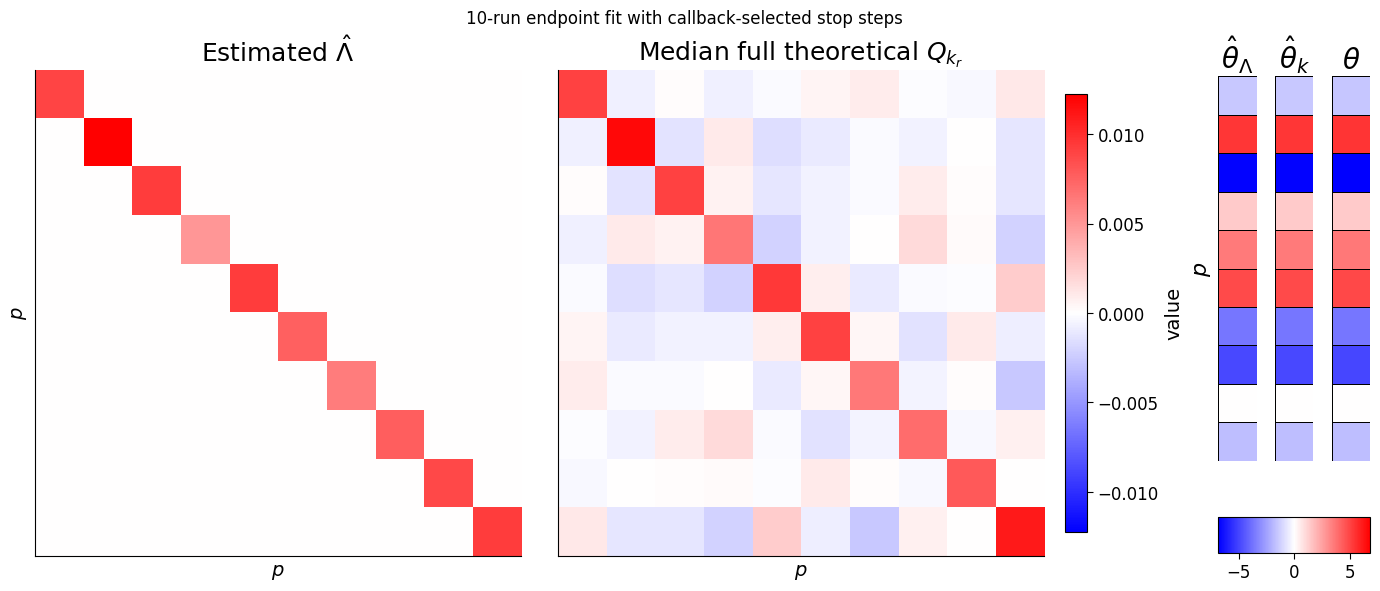

10-run endpoint diagonal distance to weighted theory target: 0.003663
10-run endpoint matrix distance to median full theory target: 0.010248
linear_regression_trajectory_fig3_10run_endpoint.pdf


In [32]:
theta_endpoints = torch.stack([run["model_theta"] for run in run_data])
endpoint_targets = torch.stack([run["neg_grad_stop"] for run in run_data])
Q_theory_points = torch.stack([run["Q_theory_stop"] for run in run_data])
lambda_theory_points = torch.stack([run["lambda_theory_stop"] for run in run_data])

lambda_runs10 = fit_diag_from_endpoints(theta_endpoints, endpoint_targets, NUM_RUNS)
Q_runs10_est = torch.diag(lambda_runs10)
lambda_theory_runs10 = weighted_theory_diag(theta_endpoints, lambda_theory_points)
Q_theory_runs10_visual = torch.quantile(Q_theory_points, 0.5, dim=0)
dist_runs10_diag = relative_distance(lambda_runs10, lambda_theory_runs10)
dist_runs10_matrix = matrix_relative_distance(Q_runs10_est, Q_theory_runs10_visual)

fig_runs_path = FIG_DIR / "linear_regression_trajectory_fig3_10run_endpoint.pdf"
_ = plot_endpoint_comparison(
    Q_est=Q_runs10_est,
    Q_theory=Q_theory_runs10_visual,
    X=X,
    y=single["y"],
    theta_hat=single["model_theta"],
    theta_true=single["beta"],
    out_path=fig_runs_path,
    title="10-run endpoint fit with callback-selected stop steps",
    theory_panel_title="Median full theoretical $Q_{k_r}$",
)

print(f"10-run endpoint diagonal distance to weighted theory target: {dist_runs10_diag:.6f}")
print(f"10-run endpoint matrix distance to median full theory target: {dist_runs10_matrix:.6f}")
print(fig_runs_path.name)


## 2) Bootstrap endpoint recovery for one base seed

Fix the first base run and fit one shared diagonal estimator from its full-data endpoint plus `B = 100` bootstrap retrains on resampled rows of `(X, y)`.

This is the same per-seed bootstrap construction used by the recovery-curve calculation in section 3, shown here for a single base seed rather than summarized by a coordinate-wise median across seeds.


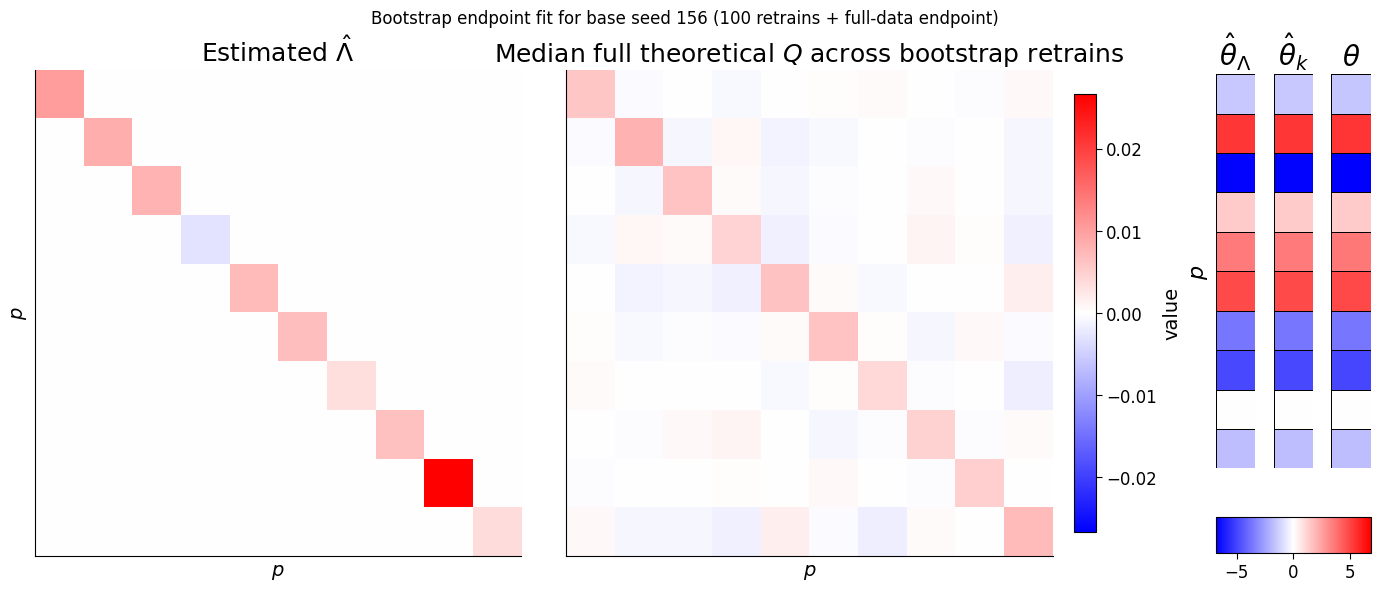

bootstrap base run index: 0 (seed 156)
bootstrap diagonal distance to weighted theory target: 0.023518
bootstrap matrix distance to median full theory target: 0.024678
linear_regression_trajectory_fig3_bootstrap.pdf


In [33]:
BOOTSTRAP_BASE_EXPERIMENT_IDX = 0
bootstrap_experiment = bootstrap_experiments[BOOTSTRAP_BASE_EXPERIMENT_IDX]
bootstrap_base_run_idx = bootstrap_experiment["base_run_idx"]
bootstrap_base_run = run_data[bootstrap_base_run_idx]
bootstrap_base_seed = SEED + 100 + bootstrap_base_run_idx

lambda_bootstrap = bootstrap_experiment["lambda_bootstrap"]
Q_bootstrap_est = bootstrap_experiment["Q_bootstrap_est"]
lambda_bootstrap_theory = bootstrap_experiment["lambda_bootstrap_theory"]
Q_bootstrap_visual = bootstrap_experiment["Q_bootstrap_visual"]

dist_bootstrap_diag = relative_distance(lambda_bootstrap, lambda_bootstrap_theory)
dist_bootstrap_matrix = matrix_relative_distance(Q_bootstrap_est, Q_bootstrap_visual)

fig_bootstrap_path = FIG_DIR / "linear_regression_trajectory_fig3_bootstrap.pdf"
_ = plot_endpoint_comparison(
    Q_est=Q_bootstrap_est,
    Q_theory=Q_bootstrap_visual,
    X=X,
    y=bootstrap_base_run["y"],
    theta_hat=bootstrap_base_run["model_theta"],
    theta_true=bootstrap_base_run["beta"],
    out_path=fig_bootstrap_path,
    title=(
        f"Bootstrap endpoint fit for base seed {bootstrap_base_seed} "
        f"({BOOTSTRAP_REPLICATES} retrains + full-data endpoint)"
    ),
    theory_panel_title="Median full theoretical $Q$ across bootstrap retrains",
)

print(f"bootstrap base run index: {bootstrap_base_run_idx} (seed {bootstrap_base_seed})")
print(f"bootstrap diagonal distance to weighted theory target: {dist_bootstrap_diag:.6f}")
print(f"bootstrap matrix distance to median full theory target: {dist_bootstrap_matrix:.6f}")
print(fig_bootstrap_path.name)


## 3) Endpoint recovery curves

The two panels below use relative distance to the relevant theoretical target as the loss proxy:

- the callback-endpoint stack is compared to its weighted stop-step target, and
- the bootstrap panel shows the seed-wise median relative distance, with an interquartile band (`25%` to `75%`) across the 10 bootstrap seed experiments.


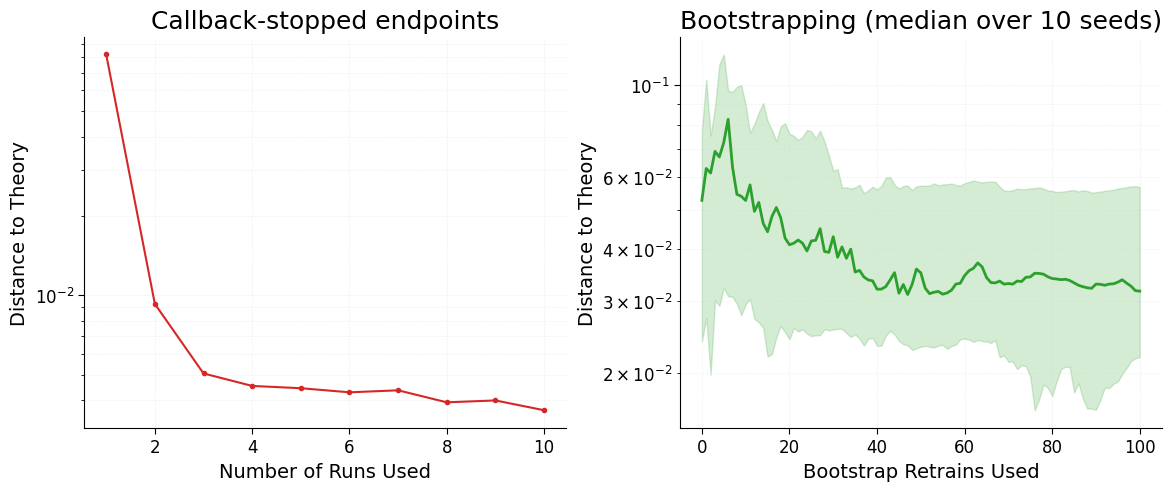

endpoint distance with 1 run: 0.081997
endpoint distance with 10 runs: 0.003663
bootstrap median distance with 0 retrains: 0.052620
bootstrap median distance with 100 retrains: 0.031688
bootstrap IQR at 100 retrains: [0.021909, 0.056627]
linear_regression_trajectory_distance_to_theory.pdf


In [34]:
run_counts = torch.arange(1, NUM_RUNS + 1)
run_distances = torch.empty(NUM_RUNS)
for i, m in enumerate(run_counts.tolist()):
    theta_m = theta_endpoints[:m]
    target_m = endpoint_targets[:m]
    theory_m = lambda_theory_points[:m]
    lam_m = fit_diag_from_endpoints(theta_m, target_m, m)
    theory_target_m = weighted_theory_diag(theta_m, theory_m)
    run_distances[i] = relative_distance(lam_m, theory_target_m)

bootstrap_distance_points = torch.stack([experiment["bootstrap_distances"] for experiment in bootstrap_experiments])
bootstrap_distance_median = torch.quantile(bootstrap_distance_points, 0.5, dim=0)
bootstrap_distance_q1 = torch.quantile(bootstrap_distance_points, 0.25, dim=0)
bootstrap_distance_q3 = torch.quantile(bootstrap_distance_points, 0.75, dim=0)

fig_dist_path = FIG_DIR / "linear_regression_trajectory_distance_to_theory.pdf"
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.8), constrained_layout=True)

plot_curve_panel(
    axes[0],
    run_counts.numpy(),
    run_distances.numpy(),
    title="Callback-stopped endpoints",
    xlabel="Number of Runs Used",
    color="#d62728",
)

axes[1].semilogy(
    bootstrap_counts.numpy(),
    bootstrap_distance_median.numpy(),
    color="#2ca02c",
    linewidth=2.0,
)
axes[1].fill_between(
    bootstrap_counts.numpy(),
    bootstrap_distance_q1.numpy(),
    bootstrap_distance_q3.numpy(),
    color="#2ca02c",
    alpha=0.2,
)
axes[1].set_title(f"Bootstrapping (median over {len(bootstrap_experiments)} seeds)")
axes[1].set_xlabel("Bootstrap Retrains Used")
axes[1].set_ylabel("Distance to Theory")
axes[1].grid(alpha=0.3, which="both")

fig.savefig(fig_dist_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(f"endpoint distance with 1 run: {run_distances[0].item():.6f}")
print(f"endpoint distance with {NUM_RUNS} runs: {run_distances[-1].item():.6f}")
print(f"bootstrap median distance with 0 retrains: {bootstrap_distance_median[0].item():.6f}")
print(f"bootstrap median distance with {BOOTSTRAP_REPLICATES} retrains: {bootstrap_distance_median[-1].item():.6f}")
print(
    f"bootstrap IQR at {BOOTSTRAP_REPLICATES} retrains: "
    f"[{bootstrap_distance_q1[-1].item():.6f}, {bootstrap_distance_q3[-1].item():.6f}]"
)
print(fig_dist_path.name)


## 4) Full-matrix endpoint recovery from independent seeds

The diagonal endpoint fit estimates only `p` regularization weights. To estimate a full symmetric regularization matrix, this section uses non-bootstrapped endpoint pools and solves a symmetric least-squares system for all `p(p + 1) / 2` entries of `Q` in

\[
-\nabla_\theta L(\hat{\theta}_{k_r}) \approx Q \hat{\theta}_{k_r}.
\]

The matrix comparison panel shows the full-matrix fit from the first `10` endpoints. The endpoint-count recovery curve uses endpoint prefixes `1..100`, averages the distance-to-theory curve over `5` independent seed pools, and uses `plt.fill_between` for the 95% standard-error band. The plotted theory target is the median full theoretical `Q_{k_r}` for each seed pool, not the final 100-endpoint least-squares fit.


In [ ]:
NUM_FULL_MATRIX_ENDPOINTS = 100
NUM_FULL_MATRIX_VIS_ENDPOINTS = 10
NUM_FULL_MATRIX_AVG_SEEDS = 5
FULL_MATRIX_SEED_STRIDE = 10000


def symmetric_matrix_design(theta_points: torch.Tensor) -> torch.Tensor:
    if theta_points.ndim != 2:
        raise ValueError("theta_points must be a rank-2 tensor")
    num_points, p = theta_points.shape
    pairs = [(i, j) for i in range(p) for j in range(i, p)]
    design = theta_points.new_zeros((num_points * p, len(pairs)))
    rows = torch.arange(num_points, device=theta_points.device) * p

    for col, (i, j) in enumerate(pairs):
        design[rows + i, col] += theta_points[:, j]
        if i != j:
            design[rows + j, col] += theta_points[:, i]
    return design


def full_matrix_record_from_run(run_idx: int, beta_seed: int, run: dict) -> dict:
    return {
        "run_idx": run_idx,
        "seed": beta_seed,
        "beta": run["beta"],
        "y": run["y"],
        "stop_step": run["stop_step"],
        "model_theta": run["model_theta"],
        "neg_grad_stop": run["neg_grad_stop"],
        "Q_theory_stop": run["Q_theory_stop"],
    }


def generate_full_matrix_record(run_idx: int, beta_seed: int) -> dict:
    g = torch.Generator().manual_seed(beta_seed)
    beta = 3.0 * torch.randn(P, generator=g)
    y = X @ beta
    stop_step, model_theta, full_traj = run_callback_training(
        X,
        y,
        EPS,
        MAX_EPOCHS,
        EARLY_STOP_PATIENCE,
        EARLY_STOP_MIN_DELTA,
    )
    theta_stopped = freeze_after_stop(full_traj["theta"], stop_step)
    loss_grad_traj = loss_grad_trajectory(X, y, theta_stopped)
    assert torch.allclose(full_traj["theta"][stop_step], model_theta, atol=1e-12)

    Q_theory_stop = compute_Q_matrix(X, stop_step, EPS)
    neg_grad_stop = -loss_grad_traj[stop_step]

    return {
        "run_idx": run_idx,
        "seed": beta_seed,
        "beta": beta,
        "y": y,
        "stop_step": stop_step,
        "model_theta": model_theta,
        "neg_grad_stop": neg_grad_stop,
        "Q_theory_stop": Q_theory_stop,
    }


def collect_full_matrix_run_data(pool_idx: int) -> list[dict]:
    pool = []
    seed_offset = pool_idx * FULL_MATRIX_SEED_STRIDE
    for endpoint_idx in range(NUM_FULL_MATRIX_ENDPOINTS):
        beta_seed = SEED + 100 + seed_offset + endpoint_idx
        if pool_idx == 0 and endpoint_idx < len(run_data):
            pool.append(full_matrix_record_from_run(endpoint_idx, beta_seed, run_data[endpoint_idx]))
        else:
            pool.append(generate_full_matrix_record(endpoint_idx, beta_seed))
    return pool


def stack_full_matrix_data(pool: list[dict]):
    theta = torch.stack([run["model_theta"] for run in pool])
    targets = torch.stack([run["neg_grad_stop"] for run in pool])
    Q_points = torch.stack([run["Q_theory_stop"] for run in pool])
    theory_targets = torch.einsum("rij,rj->ri", Q_points, theta)
    return theta, targets, Q_points, theory_targets


full_matrix_counts = torch.arange(1, NUM_FULL_MATRIX_ENDPOINTS + 1)
full_matrix_experiments = []
for pool_idx in range(NUM_FULL_MATRIX_AVG_SEEDS):
    pool = collect_full_matrix_run_data(pool_idx)
    theta_pool, targets_pool, Q_points_pool, theory_targets_pool = stack_full_matrix_data(pool)
    Q_theory_pool = torch.quantile(Q_points_pool, 0.5, dim=0)

    distances_to_theory = torch.empty(NUM_FULL_MATRIX_ENDPOINTS)
    for i, points_used in enumerate(full_matrix_counts.tolist()):
        Q_prefix = fit_symmetric_matrix_from_endpoints(theta_pool, targets_pool, points_used)
        distances_to_theory[i] = matrix_relative_distance(Q_prefix, Q_theory_pool)

    full_matrix_experiments.append(
        {
            "pool_idx": pool_idx,
            "run_data": pool,
            "theta": theta_pool,
            "targets": targets_pool,
            "Q_points": Q_points_pool,
            "theory_targets": theory_targets_pool,
            "Q_theory": Q_theory_pool,
            "distances_to_theory": distances_to_theory,
        }
    )

full_matrix_run_data = full_matrix_experiments[0]["run_data"]
visual_run_data = full_matrix_run_data[:NUM_FULL_MATRIX_VIS_ENDPOINTS]
visual_theta = full_matrix_experiments[0]["theta"][:NUM_FULL_MATRIX_VIS_ENDPOINTS]
visual_targets = full_matrix_experiments[0]["targets"][:NUM_FULL_MATRIX_VIS_ENDPOINTS]
visual_Q_points = full_matrix_experiments[0]["Q_points"][:NUM_FULL_MATRIX_VIS_ENDPOINTS]
visual_theory_targets = full_matrix_experiments[0]["theory_targets"][:NUM_FULL_MATRIX_VIS_ENDPOINTS]

Q_full_matrix_est = fit_symmetric_matrix_from_endpoints(
    visual_theta,
    visual_targets,
    NUM_FULL_MATRIX_VIS_ENDPOINTS,
)
Q_full_matrix_visual = torch.quantile(visual_Q_points, 0.5, dim=0)

dist_full_matrix_visual = matrix_relative_distance(Q_full_matrix_est, Q_full_matrix_visual)
full_matrix_target_mismatch = torch.max(torch.abs(visual_targets - visual_theory_targets)).item()
full_matrix_stop_steps = torch.tensor([run["stop_step"] for run in visual_run_data], dtype=torch.float32)
full_matrix_stop_median = torch.quantile(full_matrix_stop_steps, 0.5).item()
full_matrix_stop_q1 = torch.quantile(full_matrix_stop_steps, 0.25).item()
full_matrix_stop_q3 = torch.quantile(full_matrix_stop_steps, 0.75).item()
visual_symmetric_design = symmetric_matrix_design(visual_theta)
full_matrix_design_rank = torch.linalg.matrix_rank(visual_symmetric_design).item()
full_matrix_design_condition = torch.linalg.cond(visual_symmetric_design).item()
full_matrix_min_eig = torch.linalg.eigvalsh(Q_full_matrix_est).min().item()

full_matrix_distance_points = torch.stack(
    [experiment["distances_to_theory"] for experiment in full_matrix_experiments]
)
full_matrix_distance_mean = full_matrix_distance_points.mean(dim=0)
full_matrix_distance_sem95 = (
    1.96 * full_matrix_distance_points.std(dim=0, unbiased=True) / (NUM_FULL_MATRIX_AVG_SEEDS ** 0.5)
)
full_matrix_distance_lower = (full_matrix_distance_mean - full_matrix_distance_sem95).clamp_min(1e-12)
full_matrix_distance_upper = full_matrix_distance_mean + full_matrix_distance_sem95

fig_full_matrix_path = FIG_DIR / "linear_regression_trajectory_fig4_10endpoint_full_matrix.pdf"
_ = plot_endpoint_comparison(
    Q_est=Q_full_matrix_est,
    Q_theory=Q_full_matrix_visual,
    X=X,
    y=visual_run_data[0]["y"],
    theta_hat=visual_run_data[0]["model_theta"],
    theta_true=visual_run_data[0]["beta"],
    out_path=fig_full_matrix_path,
    title=f"10-endpoint symmetric full-matrix fit ({P * (P + 1) // 2} parameters)",
    theory_panel_title="Median full theoretical $Q_{k_r}$ over 10 endpoints",
    estimate_panel_title=r"Estimated $\hat{Q}$",
    ridge_theta_title=r"$\hat{\theta}_{Q}$",
)

fig_full_matrix_dist_path = FIG_DIR / "linear_regression_trajectory_full_matrix_distance_to_theory.pdf"
fig, ax = plt.subplots(figsize=(6.2, 4.8), constrained_layout=True)
counts_np = full_matrix_counts.numpy()
ax.semilogy(
    counts_np,
    full_matrix_distance_mean.numpy(),
    marker="o",
    markersize=3,
    color="#9467bd",
    label="Mean distance to theory",
)
plt.fill_between(
    counts_np,
    full_matrix_distance_lower.numpy(),
    full_matrix_distance_upper.numpy(),
    color="#9467bd",
    alpha=0.2,
    label="95% SE",
)
ax.axvline(
    NUM_FULL_MATRIX_VIS_ENDPOINTS,
    color="#222222",
    linestyle=":",
    linewidth=1.2,
    label=f"{NUM_FULL_MATRIX_VIS_ENDPOINTS} endpoints",
)
# ax.set_title("Full-matrix endpoint recovery")
ax.set_xlabel("Number of Endpoints Used")
ax.set_ylabel("Distance to Theory")
ax.set_xlim(1, NUM_FULL_MATRIX_ENDPOINTS)
ax.grid(alpha=0.3, which="both")
ax.legend(frameon=False)
fig.savefig(fig_full_matrix_dist_path, bbox_inches="tight")
display(fig)
plt.close(fig)


def format_mean_interval(values: torch.Tensor, errors: torch.Tensor, idx: int) -> str:
    mean = values[idx].item()
    err = errors[idx].item()
    lower = max(mean - err, 0.0)
    upper = mean + err
    return f"{mean:.6f} [{lower:.6f}, {upper:.6f}]"


print(f"full-matrix visual endpoints used: {len(visual_run_data)}")
print(f"full-matrix curve seed pools averaged: {NUM_FULL_MATRIX_AVG_SEEDS}")
print(
    f"full-matrix symmetric design rank: {full_matrix_design_rank}/{P * (P + 1) // 2}; "
    f"condition number: {full_matrix_design_condition:.3e}"
)
print(f"full-matrix visual stop-step median [IQR]: {full_matrix_stop_median:.1f} [{full_matrix_stop_q1:.1f}, {full_matrix_stop_q3:.1f}]")
print(f"max endpoint-vs-theory target mismatch over visual endpoints: {full_matrix_target_mismatch:.6e}")
print(f"10-endpoint full-matrix distance to median full theory matrix: {dist_full_matrix_visual:.6f}")
print(
    "full-matrix mean distance to theory with 1 endpoint [95% SE]: "
    f"{format_mean_interval(full_matrix_distance_mean, full_matrix_distance_sem95, 0)}"
)
print(
    f"full-matrix mean distance to theory with {NUM_FULL_MATRIX_VIS_ENDPOINTS} endpoints [95% SE]: "
    f"{format_mean_interval(full_matrix_distance_mean, full_matrix_distance_sem95, NUM_FULL_MATRIX_VIS_ENDPOINTS - 1)}"
)
print(
    f"full-matrix mean distance to theory with {NUM_FULL_MATRIX_ENDPOINTS} endpoints [95% SE]: "
    f"{format_mean_interval(full_matrix_distance_mean, full_matrix_distance_sem95, NUM_FULL_MATRIX_ENDPOINTS - 1)}"
)
print(f"full-matrix estimated min eigenvalue: {full_matrix_min_eig:.6e}")
print(fig_full_matrix_path.name)
print(fig_full_matrix_dist_path.name)


In [36]:
print("Generated files:")
print(fig_runs_path.name)
print(fig_bootstrap_path.name)
print(fig_dist_path.name)
print(fig_full_matrix_path.name)
print(fig_full_matrix_dist_path.name)


Generated files:
linear_regression_trajectory_fig3_10run_endpoint.pdf
linear_regression_trajectory_fig3_bootstrap.pdf
linear_regression_trajectory_distance_to_theory.pdf
linear_regression_trajectory_fig4_10endpoint_full_matrix.pdf
linear_regression_trajectory_full_matrix_distance_to_theory.pdf
